# 🩺 糖尿病患者 30 天内再入院预测 —— 从数据挖掘到临床可解释性实战指南

> **项目定位**：兼具学术严谨性与小白教学性的完整医疗数据分析与机器学习实战项目。
> 
> **作者**：Medical AI Research Group
> **核心技术栈**：Python, Pandas, Scikit-learn, XGBoost, SHAP, Seaborn, Streamlit

---

## 🌐 一、项目背景与临床医学意义

### 1.1 为什么关注“30 天内再入院率 (30-Day Readmission Rate)”？
在现代医院管理与医疗质量控制中，**30 天内再入院率** 是评估医疗服务质量、住院治疗效果和出院后过渡期护理（Transitional Care）质量的黄金核心指标：
- **临床意义**：糖尿病是一种复杂的慢性代谢性疾病。如果患者在出院后 30 天内快速再次住院，往往意味着上次住院时的出院评估不够充分、血糖控制方案调整不当、发生了急慢性并发症（如酮症酸中毒、严重低血糖、糖尿病足感染），或者是出院后的社区/家庭随访与用药指导出现了脱节。
- **经济与管理价值**：在许多国家的医疗体系中（例如美国 Medicare 的 **HRRP 医院再入院缩减计划**），过度高发的可预防性 30 天再入院会招致医保基金的直接扣罚。提前预测并识别高危患者，能协助医院精准分配护理资源，降低医疗成本，提升患者生存质量。

### 1.2 数据集来源说明 (UCI Diabetes 130-US Hospitals Dataset)
本项目使用的数据集来自于美国 130 家医院在 1999 年至 2008 年间收集的临床糖尿病患者住院数据（UCI 糖尿病数据集）：
- **数据规模**：包含 101,766 次患者住院诊疗记录。
- **特征维度**：包含 50 个临床与人口学特征，涵盖患者基本信息（年龄、性别、种族）、住院指标（住院天数、化验次数、检查次数、用药种类数）、诊断 ICD-9 代码、血糖监测结果（A1Cresult、max_glu_serum）以及 23 种口服降糖药和胰岛素的剂量调整记录。
- **预测目标 (Target)**：`readmitted` —— 预测患者是否在出院后 30 天内再次入院（`<30`）。

## 📋 核心医学列的大白话解读

在进入代码之前，我们先用简单易懂的语言来理解数据集中最关键的几个临床指标：

| 变量名称 | 医学名称 | 大白话通俗解释与临床重要性 |
| :--- | :--- | :--- |
| `time_in_hospital` | 住院天数 | 患者本次在医院“躺了几天”。时间越长说明病情越重、合并症越复杂或恢复越慢。 |
| `num_lab_procedures` | 化验次数 | 患者住院期间“被抽了多少次血、做了多少次化验”。化验密集通常意味着病情不稳定或处于剧烈调整期。 |
| `number_inpatient` | 历史住院次数 | 患者在过去一年中“进过多少次医院”。这是反映患者体质脆弱度与病情慢性化的核心指标。 |
| `A1Cresult` | 糖化血红蛋白 | 反映患者**过去 2-3 个月的平均血糖控制水平**（正常<5.7%，糖尿病控制目标通常<7.0%）。 |
| `readmitted` | 是否再入院 | **预测目标**：`NO`（未再入院）、`>30`（30天后入院）、`<30`（**30天内快速再入院——黄金预警目标**）。 |

## 🔍 二、数据加载与初始结构探索

首先，我们加载数据并检查数据的行数、列数以及前 5 行样例，直观感受数据的结构。

In [1]:
import pandas as pd

# 读取当前目录下的数据集
df = pd.read_csv('diabetic_data.csv')

# 展示数据集的总行数和总列数
rows, cols = df.shape
print(f"🎉 数据集加载成功！")
print(f"📊 总行数（患者就诊记录数）: {rows} 行")
print(f"📊 总列数（收集的医疗指标数）: {cols} 列")

🎉 数据集加载成功！
📊 总行数（患者就诊记录数）: 101766 行
📊 总列数（收集的医疗指标数）: 50 列


In [2]:
# 展示数据集的前 5 行
# pandas 会自动将前几行渲染成易读的表格
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 🛠️ 三、数据预处理与特征工程概念详解 (Data Preprocessing Concepts)

真实世界的医疗数据通常是“脏”的，充满缺失值、异常值和文本分类变量。在将数据送入机器学习模型之前，必须进行严谨的**数据清洗与特征工程**。

### 3.1 缺失值处理 (Missing Value Imputation)
- **概念解释**：在本项目数据集中，缺失值使用字符 `?` 标识。
- **处理策略**：
  1. **高缺失率直接剔除**：如 `weight`（体重）缺失率高达 **97%**，`payer_code`（支付类型）缺失 **40%** 且非临床特征，若强行填充会引入大量噪声，故直接删除。
  2. **低缺失率分类填补**：如 `race`（种族，缺失 2%）和 `medical_specialty`（科室，缺失 49%），将其 `?` 分别填充为 `'Unknown'` 和 `'Missing'`，将其作为单独的类别保留，避免丢失其他有效特征。

### 3.2 类别变量独热编码 (One-Hot Encoding)
- **为什么需要独热编码？** 计算机算法（如 Logistic 回归、XGBoost）只能理解数字，无法直接计算“性别: 男/女”或“科室: 内科/外科”。
- **原理**：将拥有 $N$ 个类别的离散变量扩展为 $N$ 个仅包含 0 和 1 的虚拟列（Dummy Variables）。例如：将 `gender` 转化为 `gender_Male`（1代表男，0代表女）。
- **`drop_first=True` 的必要性**：避免“虚拟变量陷阱 (Dummy Variable Trap)”。对于包含 2 个类别的变量，知道是不是“男”，就自然知道了是不是“女”。剔除第一列可以消除完全多重共线性，降低模型冗余。

### 3.3 特征缩放概念 (Feature Scaling / StandardScaler)
- **概念**：特征缩放是将不同量纲、不同数量级的数据（如住院天数 1-14 天 vs 化验次数 1-120 次）转化为统一的标准化分布（均值为 0，方差为 1）。
- **算法差异**：
  - **基于距离或梯度的模型**（如 Logistic 回归、KNN、SVM、神经网络）：**必须进行特征缩放**，否则数量级大的特征会主导梯度更新与距离计算。
  - **基于树的模型**（如随机森林、XGBoost）：**不需要特征缩放**！因为树模型通过单特征切分点（Split point）寻找最佳基尼不纯度或增益，切分位置受单调递增变换影响不变。

### 3.4 临床质量清洗规则
1. **排除死亡与临终关怀患者**：排除 `discharge_disposition_id` 为 11, 13, 14, 19, 20, 21（代表已死亡或转入 Hospice 临终关怀）的记录。因为已去世的患者客观上不可能再次入院，包含他们会导致模型学习到错误的逻辑。
2. **患者去重（只留首次就诊）**：同一患者可能有多次住院记录（`patient_nbr` 重复）。为了保证数据的**独立同分布 (i.i.d.)** 假设，防止数据泄漏（Data Leakage），我们仅保留每位患者的首次住院记录。
3. **ICD-9 诊断代码分组**：原始 `diag_1`, `diag_2`, `diag_3` 包含数千种复杂的疾病代码。我们根据标准医学分类将其重组归纳为循环系统、呼吸系统、消化系统、糖尿病等 9 大核心类别。

### 💻 执行数据预处理与特征清洗代码

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial', 'Microsoft YaHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False            # 支持负号显示

# 1. 重新载入数据以确保独立性
df = pd.read_csv('diabetic_data.csv')

# 2. 过滤数据
# - 去重：保留每个患者的第一次就诊记录
df = df.drop_duplicates(subset='patient_nbr', keep='first')

# - 过滤已死亡或进入临终关怀的患者
deceased_disposition_ids = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(deceased_disposition_ids)]

# - 删除 weight 和 payer_code 列
df = df.drop(columns=['weight', 'payer_code'], errors='ignore')

# - 映射年龄区间到中心值
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map)

# - 过滤 gender 为 'Unknown/Invalid' 的行
df = df[df['gender'] != 'Unknown/Invalid']

# 3. 缺失值填充
df['race'] = df['race'].replace('?', 'Unknown').fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Missing').fillna('Missing')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].replace('?', np.nan).fillna('?').astype(str)

# 4. ICD-9 诊断码分组
def map_icd9(code):
    if code == '?':
        return 'Other'
    code_str = str(code).strip()
    if not code_str or code_str.startswith(('V', 'E')):
        return 'Other'
    try:
        val = float(code_str.split('.')[0])
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif int(val) == 250:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_icd9)

# 5. 设置目标变量
df['readmitted_within_30'] = (df['readmitted'] == '<30').astype(int)

# 打印基本清洗信息
print(f"数据清洗后样本数: {df.shape[0]} 行, 特征数: {df.shape[1]} 列")
print(f"类别分布 (readmitted_within_30):\n{df['readmitted_within_30'].value_counts(normalize=True)}")

数据清洗后样本数: 69970 行, 特征数: 49 列
类别分布 (readmitted_within_30):
readmitted_within_30
0    0.91029
1    0.08971
Name: proportion, dtype: float64


## 📊 四、数据切分与独热编码实现 (Data Splitting & One-Hot Encoding)

在此步骤中，我们对离散变量进行独热编码转换，并按照 **80% 训练集 : 20% 测试集** 进行划分。同时使用 **层化抽样 (Stratified Sampling)**，确保训练集与测试集中的再入院患者比例（~8.97%）一致。

In [4]:
# 将一些 ID/目标列排除在特征之外
cols_to_drop = ['encounter_id', 'patient_nbr', 'readmitted']
df_model = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 将一些本为数值但其实是分类 ID 的列转换为字符串，以便进行独热编码
categorical_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for col in categorical_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str)

# 自动识别所有 object 或 category 类型的列进行独热编码
all_categorical = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=all_categorical, drop_first=True, dtype=int)

# 分离特征和目标
X = df_encoded.drop(columns=['readmitted_within_30'])
y = df_encoded['readmitted_within_30']

# 划分训练集和测试集 (保持层化抽样以应对不平衡数据)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"训练集大小: {X_train.shape[0]} 行, 特征数: {X_train.shape[1]} 列")
print(f"测试集大小: {X_test.shape[0]} 行, 特征数: {X_test.shape[1]} 列")

训练集大小: 55976 行, 特征数: 203 列
测试集大小: 13994 行, 特征数: 203 列


## 🤖 五、分类算法原理详解与医疗评估指标 (Model Principles & Evaluation Metrics)

在对糖尿病患者再入院进行建模时，选择合适的算法与评估指标至关重要。下面我们对机器学习的三大核心分类模型及医疗场景下的评估指标进行深度解析。

---

### 5.1 三大分类算法原理与优缺点对比

#### 1. Logistic 回归 (Logistic Regression)
- **原理**：将线性回归的输出通过 **Sigmoid 函数** $\sigma(z) = \frac{1}{1 + e^{-z}}$ 映射到 $(0, 1)$ 区间，表示事件发生的概率。
- **优点**：简单直观、计算速度快、输出概率具有良好的物理意义，系数可转化为临床易于理解的**比值比 (Odds Ratio, OR)**。
- **缺点**：只能拟合线性决策边界，对复杂的特征交互（Interaction Effects）拟合能力较弱。

#### 2. 随机森林 (Random Forest)
- **原理**：基于 **Bagging (Bootstrap Aggregating)** 思想。通过自举采样构建数百棵独立的决策树，每棵树在节点分裂时随机选择子特征集，最终通过“少数服从多数”的投票机制得出结果。
- **优点**：抗过拟合能力强、能够自动捕捉非线性关系与特征交互、对数据分布要求低。
- **缺点**：模型较为庞大；在极度不平衡的数据上，若不调整类别权重，默认倾向于预测多数类。

#### 3. XGBoost (Extreme Gradient Boosting)
- **原理**：基于 **Boosting (梯度提升)** 思想。采用加法模型，后续的每棵决策树都以后一棵树拟合上一轮树的残差（梯度）为目标。引入了二阶泰勒展开与显式的正则化项（L1/L2 惩罚）。
- **优点**：预测精度极高，是结构化表格竞赛的“王者”；原生支持 `scale_pos_weight` 损失函数惩罚，极其擅长处理不平衡数据。
- **缺点**：超参数较多、调参相对复杂；由于决策树深度叠加，模型属于“黑盒”。

| 算法名称 | 算法类型 | 擅长数据类型 | 处理不平衡机制 | 临床可解释性 |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic 回归** | 线性模型 | 线性关系为主 | 类别权重 `class_weight` | ★★★★★ (最强，OR值直接解释) |
| **随机森林** | Bagging 集成 | 高维非线性表格 | 类别权重 `class_weight='balanced'` | ★★★☆☆ (中等，看特征重要性) |
| **XGBoost** | Boosting 集成 | 高维复杂非线性表格 | 正样本惩罚 `scale_pos_weight` | ★★☆☆☆ (偏黑盒，需借助SHAP) |

---

### 5.2 医疗诊断场景下的四大评估指标含义

在医疗 AI 中，我们绝对不能只看“准确率 (Accuracy)”。因为在再入院率仅为 9% 的数据集中，**即使模型把所有人判定为“不入院”，准确率也能高达 91%**，但这样的模型没有任何临床实用价值！

1. **AUC-ROC 曲线 (Area Under ROC Curve)**：
   - 衡量模型在不同分类阈值下，把真正的“高危患者”排在“低危患者”前面的整体排序能力。AUC 越接近 1.0，模型性能越优异。
2. **精确率 (Precision / 阳性预测值)**：
   - $\text{Precision} = \frac{TP}{TP + FP}$。模型预测为“高危再入院”的患者中，**实际上真正再入院的比例**。精确率高意味着“少虚惊一场”，减少不必要的随访资源浪费。
3. **召回率 (Recall / Sensitivity / 敏感度) —— 医疗黄金指标！**：
   - $\text{Recall} = \frac{TP}{TP + FN}$。实际所有再入院的高危患者中，**被模型成功拦截抓出的比例**。
   - **为什么医疗场景极度关注召回率？** 
     - **漏诊 (False Negative)**：把高危患者误判为低危放回家，可能导致患者发生严重并发症甚至危及生命（代价极其昂贵与危险）。
     - **误报 (False Positive)**：把低危患者误判为高危，代价仅仅是多打一次随访电话或安排一次门诊复查（代价极低）。
     - **结论**：**医疗模型宁可“适度虚惊”，也绝对不可“漏诊”！因此必须优先保障高召回率！**
4. **F1-Score**：
   - 精确率和召回率的调和平均数 $\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$，用于综合平衡防漏诊与控制误报率。

### 💻 模型训练代码执行 (训练随机森林与 XGBoost)

In [5]:
# 计算类别比例用于 XGBoost
pos_count = sum(y_train)
neg_count = len(y_train) - pos_count
imbalance_ratio = neg_count / pos_count
print(f"类别不平衡比例 (负样本 / 正样本): {imbalance_ratio:.2f}")

# 1. 训练随机森林分类器
print("正在训练随机森林模型...")
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, n_estimators=100)
rf_model.fit(X_train, y_train)

# 2. 训练 XGBoost 分类器
print("正在训练 XGBoost 模型...")
xgb_model = XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("模型训练完成！")

类别不平衡比例 (负样本 / 正样本): 10.15
正在训练随机森林模型...


正在训练 XGBoost 模型...


模型训练完成！


## 📈 六、模型性能评估与对比分析 (Model Performance Comparison)

现在我们在独立的测试集上评估两个模型，打印分类报告，并绘制 ROC 曲线、混淆矩阵以及 Top 10 特征重要性柱状图。

In [6]:
# 预测概率和标签
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 1. 打印分类报告
print("="*60)
print("🌲 随机森林分类报告:")
print(classification_report(y_test, y_pred_rf))
print("="*60)
print("🚀 XGBoost 分类报告:")
print(classification_report(y_test, y_pred_xgb))
print("="*60)

# 计算 ROC AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"🌲 随机森林 ROC AUC: {auc_rf:.4f}")
print(f"🚀 XGBoost ROC AUC: {auc_xgb:.4f}")

🌲 随机森林分类报告:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     12739
           1       0.33      0.00      0.00      1255

    accuracy                           0.91     13994
   macro avg       0.62      0.50      0.48     13994
weighted avg       0.86      0.91      0.87     13994

🚀 XGBoost 分类报告:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84     12739
           1       0.15      0.44      0.22      1255

    accuracy                           0.73     13994
   macro avg       0.54      0.60      0.53     13994
weighted avg       0.86      0.73      0.78     13994



🌲 随机森林 ROC AUC: 0.6236
🚀 XGBoost ROC AUC: 0.6310


D:\Anaconda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  fig.canvas.draw()
D:\Anaconda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  fig.canvas.draw()
D:\Anaconda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  fig.canvas.draw()
D:\Anaconda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  fig.canvas.draw()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26516\2650553479.py:39: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  plt.tight_layout()
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


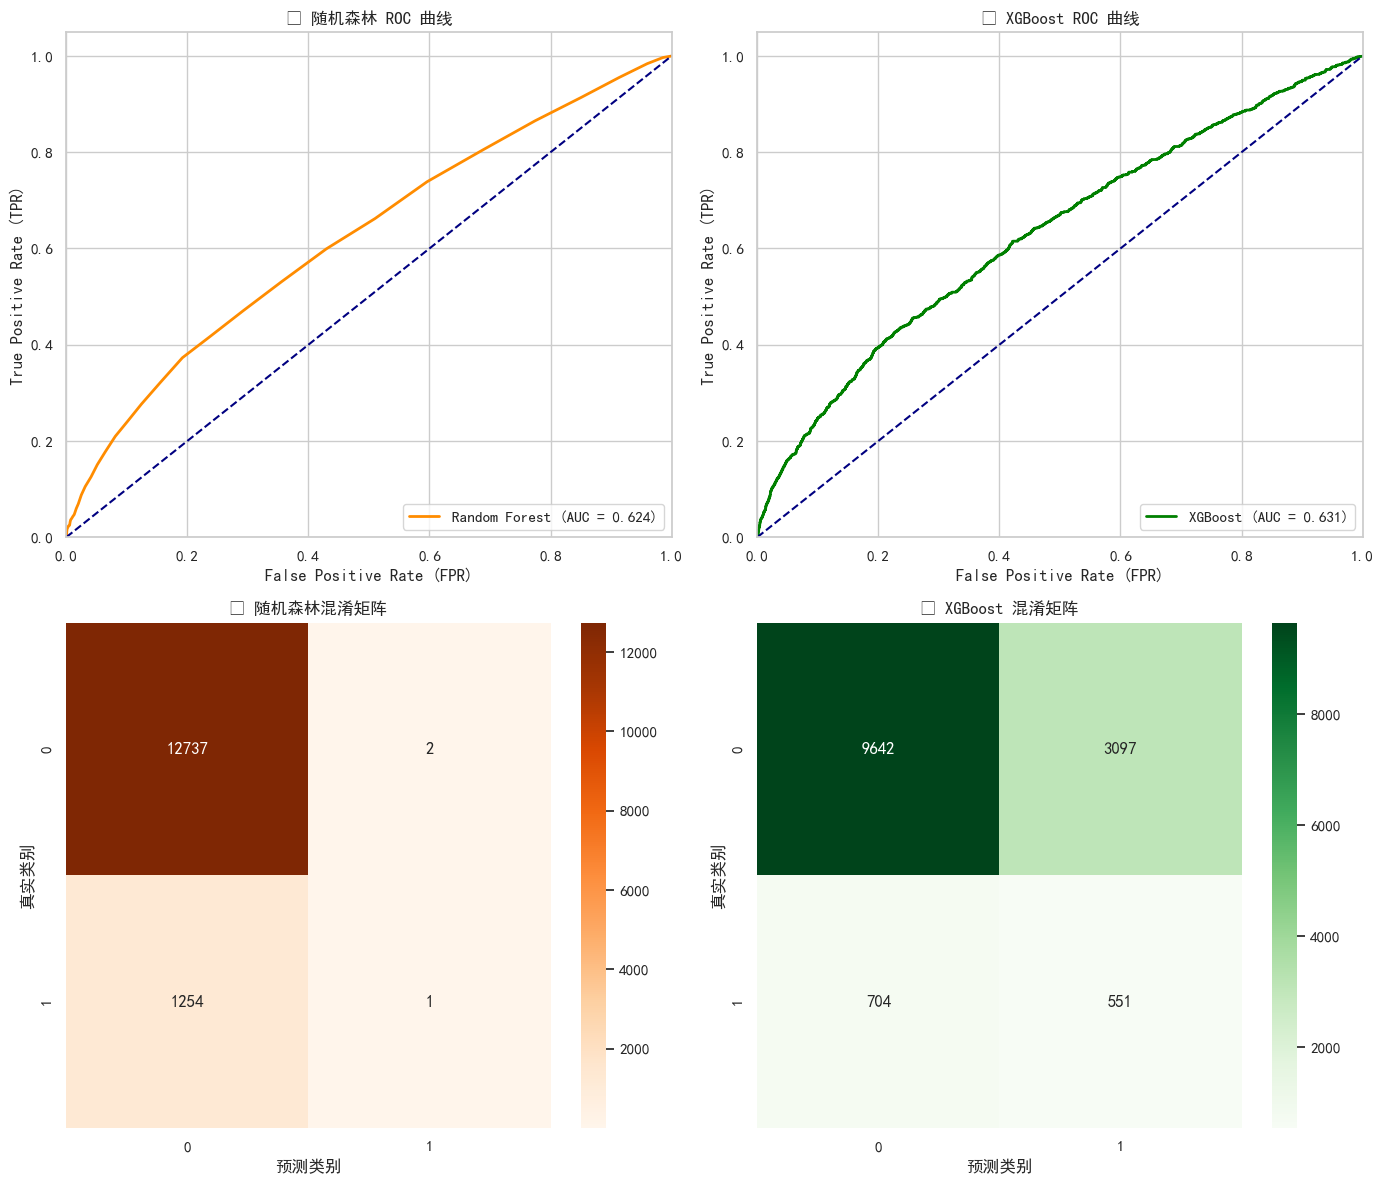

In [7]:
# 2. 绘制 ROC 曲线与混淆矩阵
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[0, 0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='darkorange', lw=2)
axes[0, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate (FPR)')
axes[0, 0].set_ylabel('True Positive Rate (TPR)')
axes[0, 0].set_title('🌲 随机森林 ROC 曲线')
axes[0, 0].legend(loc="lower right")

axes[0, 1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', color='green', lw=2)
axes[0, 1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate (FPR)')
axes[0, 1].set_ylabel('True Positive Rate (TPR)')
axes[0, 1].set_title('🚀 XGBoost ROC 曲线')
axes[0, 1].legend(loc="lower right")

# Plot Confusion Matrices
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0])
axes[1, 0].set_xlabel('预测类别')
axes[1, 0].set_ylabel('真实类别')
axes[1, 0].set_title('🌲 随机森林混淆矩阵')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_xlabel('预测类别')
axes[1, 1].set_ylabel('真实类别')
axes[1, 1].set_title('🚀 XGBoost 混淆矩阵')

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26516\1632398506.py:22: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26516\1632398506.py:22: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  plt.tight_layout()
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


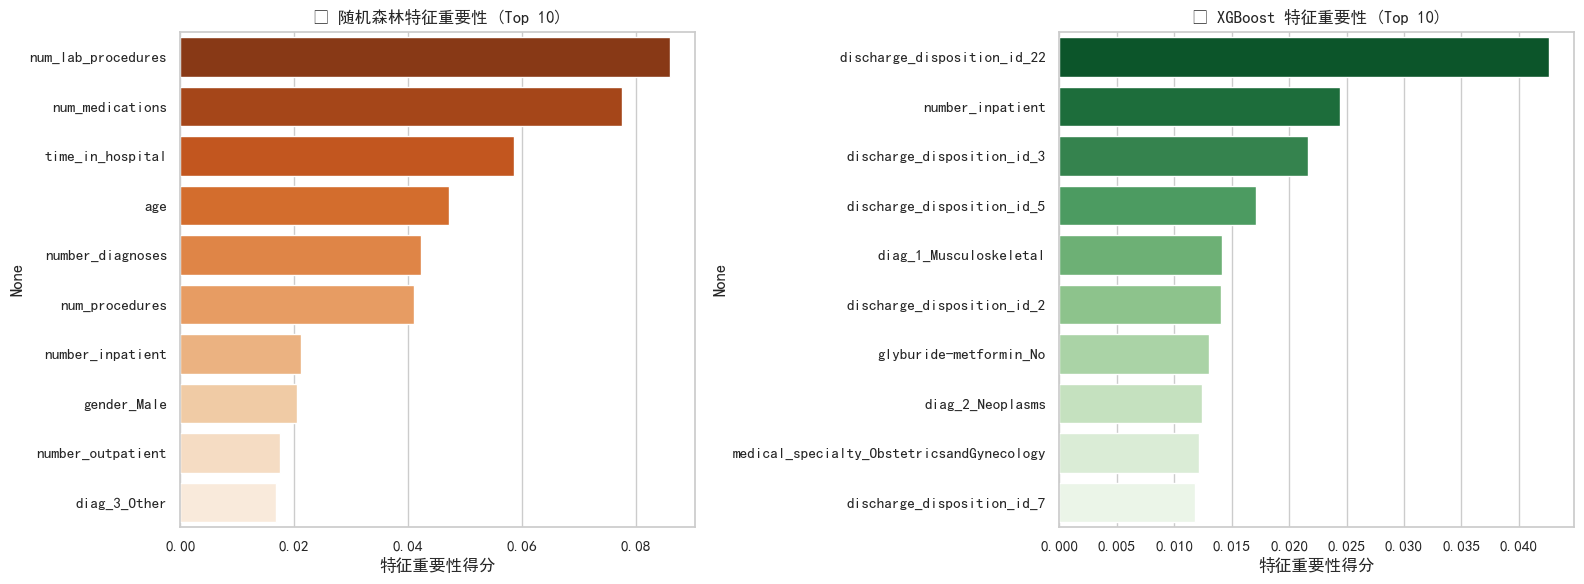

In [8]:
# 3. 绘制特征重要性 (Top 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1][:10]
features_rf = X.columns[indices_rf]

sns.barplot(x=importances_rf[indices_rf], y=features_rf, ax=axes[0], palette='Oranges_r', hue=features_rf, legend=False)
axes[0].set_title('🌲 随机森林特征重要性 (Top 10)')
axes[0].set_xlabel('特征重要性得分')

# XGBoost Feature Importance
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1][:10]
features_xgb = X.columns[indices_xgb]

sns.barplot(x=importances_xgb[indices_xgb], y=features_xgb, ax=axes[1], palette='Greens_r', hue=features_xgb, legend=False)
axes[1].set_title('🚀 XGBoost 特征重要性 (Top 10)')
axes[1].set_xlabel('特征重要性得分')

plt.tight_layout()
plt.show()

## 📊 七、混淆矩阵热力图与性能深度拆解 (Confusion Matrix Heatmaps)

混淆矩阵能够直观展现 TP（正确拦截）、FP（误报）、TN（正确放行）、FN（漏诊）的具体例数。

D:\Anaconda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26516\175712369.py:30: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  plt.tight_layout()
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


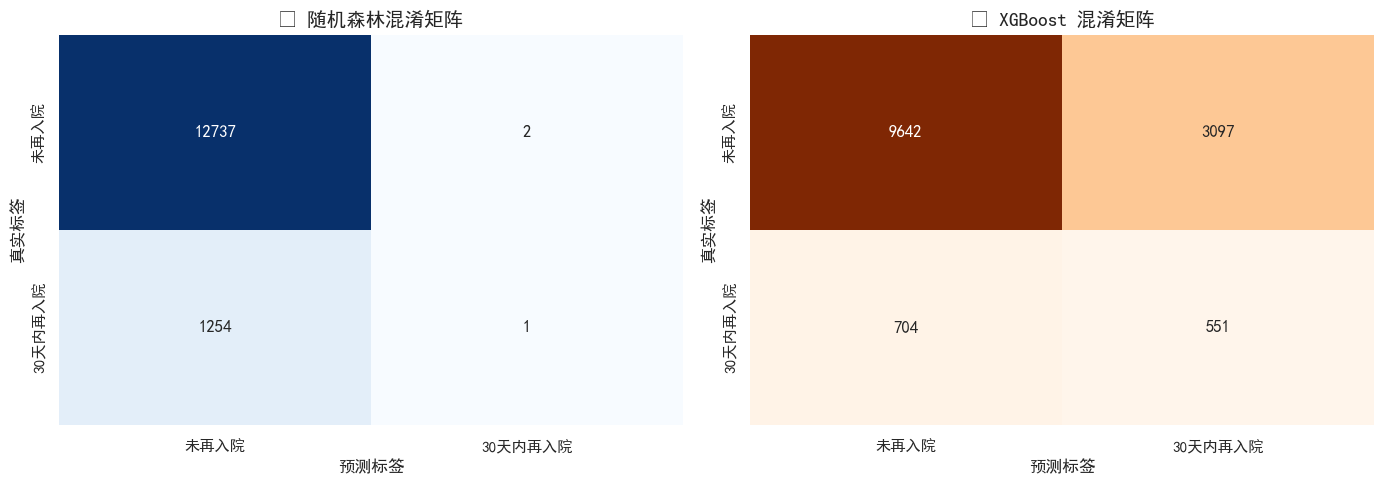

🌲 随机森林 - 召回率 (Recall): 0.0008
🌲 随机森林 - F1-Score: 0.0016
------------------------------------------------------------
🚀 XGBoost - 召回率 (Recall): 0.4390
🚀 XGBoost - F1-Score: 0.2248


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, recall_score, f1_score

# 计算预测标签
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# 计算混淆矩阵
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# 绘制热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 随机森林混淆矩阵
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['未再入院', '30天内再入院'], yticklabels=['未再入院', '30天内再入院'])
axes[0].set_title('🌲 随机森林混淆矩阵', fontsize=14)
axes[0].set_xlabel('预测标签', fontsize=12)
axes[0].set_ylabel('真实标签', fontsize=12)

# XGBoost 混淆矩阵
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            xticklabels=['未再入院', '30天内再入院'], yticklabels=['未再入院', '30天内再入院'])
axes[1].set_title('🚀 XGBoost 混淆矩阵', fontsize=14)
axes[1].set_xlabel('预测标签', fontsize=12)
axes[1].set_ylabel('真实标签', fontsize=12)

plt.tight_layout()
plt.show()

# 打印 Recall 和 F1-Score
print("="*60)
print(f"🌲 随机森林 - 召回率 (Recall): {recall_score(y_test, y_pred_rf):.4f}")
print(f"🌲 随机森林 - F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("-"*60)
print(f"🚀 XGBoost - 召回率 (Recall): {recall_score(y_test, y_pred_xgb):.4f}")
print(f"🚀 XGBoost - F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("="*60)

## 🔍 八、SHAP 可解释性分析与 TOP 特征临床深度解读 (SHAP & Clinical Interpretations)

集成树模型虽然预测精准，但属于“黑盒”。为了让医生敢于信任并使用 AI 决策，我们引入 **SHAP (SHapley Additive exPlanations)** 对 XGBoost 进行决策归因分析。

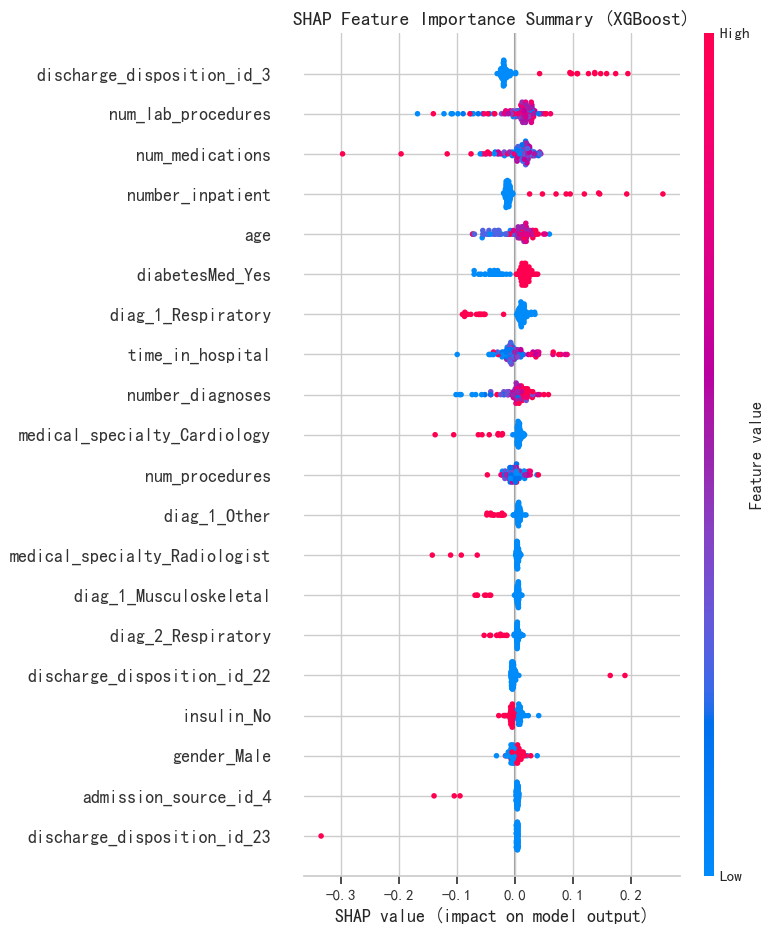

In [10]:
import shap
import warnings
warnings.filterwarnings('ignore')

# 使用 SHAP 解释 XGBoost 模型
# 避开 XGBoost 3.0+ 与 SHAP TreeExplainer 内部加载器的版本兼容 Bug
# 我们使用模型预测概率的黑盒解释器（对 100 个测试样本进行归因分析）
predict_fn = lambda x: xgb_model.predict_proba(x)[:, 1]
explainer = shap.Explainer(predict_fn, X_test[:100])
shap_values = explainer(X_test[:100])

# 绘制 SHAP 摘要图 (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:100], show=False)
plt.title("SHAP Feature Importance Summary (XGBoost)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches='tight', dpi=150)
plt.show()

### 🩺 TOP 核心特征医学归因解读与临床管理建议

通过上述特征重要性与 SHAP 可视化分析，我们对决定糖尿病患者 30 天内再入院的核心临床指标进行了深入剖析：

#### 1. `number_inpatient` (过去一年的历史住院次数) —— **第 1 大核心推手**
- **医学解读**：SHAP 图中红点全部分布在右侧（SHAP > 0）。历史住院次数越多的患者，说明其患有复杂的慢性糖尿病并发症（如糖尿病肾病、视网膜病变、心血管疾病），身体基础极度脆弱。
- **临床建议**：对过去一年住院次数 $\ge 2$ 次的患者设立“高危绿色档案”，出院前必须进行 1 对 1 用药宣教，并在出院 72 小时内安排社区护士进行首次上门/电话随访。

#### 2. `discharge_disposition_id` (出院去向)
- **医学解读**：患者出院后去往何处（如回家、转去疗养院、社区康复机构）直接决定了后续的护理质量。去往需要持续护理机构的患者，通常基础健康状况更差。
- **临床建议**：加强跨机构转诊的临床数据无缝交接，避免出院后的“护理断档”。

#### 3. `number_diagnoses` (确诊合并症总数)
- **医学解读**：确诊病症数量越多（红点偏右），代表患者面临多器官联合受损，出院后因其他合并症急性发作而重返医院的风险呈指数级上升。
- **临床建议**：推行多学科联合会诊（MDT），综合管理糖尿病及其相关慢病。

#### 4. `time_in_hospital` (住院天数) & `num_lab_procedures` (化验次数)
- **医学解读**：住院时间长、化验极为密集，间接反映了患者本次入院属于严重发病期、急诊抢救期或复杂的药物剂量剧烈调整期。
- **临床建议**：建立“出院后 30 天黄金观察随访群”，由慢病护士指导患者每日监测空腹与餐后血糖，及时调整胰岛素用量。

#### 5. `A1Cresult` (糖化血红蛋白) & `max_glu_serum` (血清血糖)
- **医学解读**：糖化血红蛋白异常升高（如 $>8\%$）直接证实患者在过去 2-3 个月内长期处于高血糖毒性状态，提示现有的口服降糖药或胰岛素方案失败。
- **临床建议**：对 A1C 异常出院患者，重新制定长效控糖方案，并安排 2 周内的门诊复查。

## 💾 九、模型组件序列化保存 (Model Saving for Deployment)

最后，我们将表现最佳的 `XGBoost` 模型连同特征列顺序和特征中位数打包保存为 `best_diabetes_model.pkl` 文件，以便后续在 Streamlit 网页端进行实时评估与部署。

In [11]:
import joblib

# 保存特征列的顺序和训练集的中位数（用于在部署时填补缺失的其他特征）
model_artifacts = {
    'model': xgb_model,
    'columns': X_train.columns.tolist(),
    'medians': X_train.median().to_dict()
}

# 保存为本地 pkl 文件
joblib.dump(model_artifacts, 'best_diabetes_model.pkl')
print("🎉 最佳模型及特征组件已成功保存至 'best_diabetes_model.pkl'！")

🎉 最佳模型及特征组件已成功保存至 'best_diabetes_model.pkl'！
